<a href="https://colab.research.google.com/github/ShreyaM5/Reinforcement-Learning-GridWorld/blob/main/q_learning_gridworld.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**Reinforcement Learning Grid Navigation using Q-Learning**
### Internship Project ISSA (DRDO)
### Shreya Maurya : IGDTUW (CSE-AI)

---

## Problem Statement

The objective of this project is to train an Reinforcement Learning (RL) agent to find the shortest path from a start cell to a goal cell in an n×n grid containing randomly generated obstacles. Invalid moves such as moving outside the grid or into obstacles are penalized, while reaching the goal gives a positive reward.

##Environment Design
###Grid Representation
The environment is represented as an n × n NumPy matrix.
Every cell initially contains 0.
Obstacles are represented using 1.
The agent is not stored inside the grid.
The goal is not stored inside the grid.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
n= 5
grid= np.zeros((n,n) , dtype=int)
print(grid)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


## Obstacle Generation
Obstacles are generated randomly.
Obstacles are stored in a Python set.
Duplicate obstacles are automatically avoided.
Start and Goal positions are excluded.



*  generate_obstacles() = Randomly generates obstacle positions while ensuring:

        *   no duplicates
        *   start is free
        *   goal is free
        *   Returns Obstacle Set



In [ ]:
def generate_obstacles(n, num_obstacles, start, goal):

    if n <= 0:
        print("Grid size must be positive.")
        return None

    if num_obstacles > (n * n - 2):
        print(f"Invalid number of obstacles. Maximum allowed is {n*n-2}.")
        return None

    obstacles = set()

    while len(obstacles) < num_obstacles:

        row = random.randint(0, n - 1)
        col = random.randint(0, n - 1)

        if (row, col) == start:
            continue

        elif (row, col) == goal:
            continue

        elif (row, col) in obstacles:
            continue

        else:
            obstacles.add((row, col))

    return obstacles

## GridWorld Class Implementation

The GridWorld class represents the RL environment. It initializes the grid, places obstacles, stores the start and goal states, and controls the agent's interaction with the environment.

functions:
* Render() : Creates a human-readable visualization of the environment without modifying the original grid.
* Reset()  : Resets the environment at the beginning of every episode.
* step(action) : Executes one action chosen by the agent. [0 -> UP,1 -> DOWN ,2 -> LEFT ,3 -> RIGHT]

###Reward Function
#### Condition-------------------    	Reward
* Normal Move	---------------------    (-1)
* Obstacle	  -------------------------(-20)
* Outside Grid ------------------------(-20)
* Goal---------------------------------(+100)

In [ ]:
class GridWorld:
  def __init__(self,n,num_obstacles):
        self.n =n
        self.num_obstacles = num_obstacles
        self.grid = np.zeros((n,n), dtype=int)
        self.start = (0,0)
        self.goal =  (n-1,n-1)
        self.obstacles = generate_obstacles(self.n,self.num_obstacles, self.start, self.goal)
        for row,col in self.obstacles:
                self.grid[row][col] = 1

        self.agent_position = self.start

  def render(self):
       for row in range(self.n):
            for col in range(self.n):
              if (row,col)==self.agent_position and (row,col)==self.goal:
                print('*',end=' ')
              elif (row,col)==self.agent_position:
                print('A',end=' ')
              elif (row,col)==self.start:
                print('S',end=' ')
              elif (row,col)==self.goal:
                print('G',end=' ')
              elif self.grid[row][col]==1:
                print('X',end=' ')
              else:
                print('.',end=' ')
            print()

  def reset(self):
          self.agent_position = self.start
          return self.agent_position

  def step(self,action):
          row,col = self.agent_position
          if action == 0:  #UP
               new_row = row - 1
               new_col = col

          elif action == 1: #DOWN
                new_row = row + 1
                new_col = col

          elif action == 2:  #LEFT
                  new_row = row
                  new_col = col - 1

          elif action == 3:   #RIGHT
                  new_row = row
                  new_col = col + 1
          else:
                raise ValueError("Invalid action")



          if not (0 <= new_row < self.n and 0 <= new_col < self.n):
              reward =-20
              done = False

          elif (new_row,new_col) in self.obstacles:
               reward =-20
               done = False


          elif (new_row,new_col) == self.goal:
               reward = 100
               done = True
               self.agent_position = (new_row,new_col)

          else :
               reward = -1
               done = False
               self.agent_position = (new_row,new_col)

          return self.agent_position, reward, done

  def state_to_index(self, position):
      row, col = position
      return row * self.n + col


## Testing the Environment


Before integrating Q-learning, the environment was manually tested to verify its behavior. The following scenarios were checked:

* Valid movement updates the agent position and gives a reward of -1
* Attempting to move outside the grid keeps the agent in the same position and returns a penalty.
* Attempting to move into an obstacle keeps the agent in the same position and returns a penalty.
* Reaching the goal updates the agent position, returns a positive reward, and ends the episode.

In [ ]:
env = GridWorld(5,5)

In [ ]:
env.render()

A . . X X 
. . . . X 
. . . X . 
. . X . . 
. . . . G 


In [ ]:
env.step(3)


((0, 1), -1, False)

In [ ]:
env.step(1)

((1, 1), -1, False)

In [ ]:
env.render()

S . . X X 
. A . . X 
. . . X . 
. . X . . 
. . . . G 


##Q-Table Representation
The Q-table stores the expected cumulative reward (Q-value) for every state-action pair. Each row represents a unique state in the environment, while each column represents one of the four possible actions (Up, Down, Left, Right). Initially, all Q-values are set to zero because the agent has no prior knowledge of the environment.

* Shape : (total_states,total_actions)
* State mapping :
     * flattening formula (state = row * n + col)
     * reverse mapping (row = state // n ) ( col = state % n)


In [ ]:
q_table = np.zeros((env.n * env.n, 4), dtype=float)

# Agent Class Implementation

The Agent class is responsible for learning the optimal policy using the Q-learning algorithm. It maintains a Q-table, where each row represents a state and each column represents an action. The agent selects actions using the ε-greedy strategy, updates the Q-values after every interaction with the environment, and gradually reduces exploration by decaying the epsilon value.

The class consists of the following methods:

* __init__(): Initializes the Q-table and the hyperparameters such as learning rate (α), discount factor (γ), and exploration rate (ε).
* choose_action(): Selects an action using the ε-greedy policy. With probability ε, the agent explores by choosing a random action; otherwise, it exploits by selecting the action with the highest Q-value.
* update_q_table(): Updates the Q-value of the current state-action pair using the Bellman update equation based on the received reward and the estimated future reward.
* decay_epsilon(): Gradually decreases the exploration rate after each episode, allowing the agent to shift from exploration to exploitation.

In [ ]:
class agent:
  def __init__(self, num_states, num_actions, alpha, gamma, epsilon):
    self.num_states = num_states
    self.num_actions = num_actions
    self.alpha = alpha
    self.gamma = gamma
    self.epsilon = epsilon
    self.q_table = np.zeros((num_states, num_actions), dtype=float)

  def choose_action(self,state):
        random_num= random.random()
        if(random_num<self.epsilon):
            action = random.randint(0, self.num_actions - 1)
        else:
            action = np.argmax(self.q_table[state])
        return action

  def update_q_table(self, state, action, reward, next_state, done):
        current_q = self.q_table[state][action]
        max_next_q_value = np.max(self.q_table[next_state]) if not done else 0
        target= reward + self.gamma * max_next_q_value
        td_error = target - current_q
        new_q_value = current_q + self.alpha * (td_error)
        self.q_table[state, action] = new_q_value

  def decay_epsilon(self):
      self.epsilon *= 0.955
      self.epsilon = max(self.epsilon, 0.01)

# Q-learning Algorithm
Q-learning is a model-free reinforcement learning algorithm in which an agent learns the optimal action for every state by interacting with the environment. The agent stores its knowledge in a Q-table, where each row represents a state and each column represents an action.

During training, the agent selects actions using the ε-greedy policy, receives rewards from the environment, and updates the Q-values using the Bellman update equation.

Q(s,a)=Q(s,a)+α[r+γmaxQ(s
′
,a
′
)−Q(s,a)]

where:

* α = Learning rate
* γ = Discount factor
* r = Immediate reward
* Q(s,a) = Current Q-value

# Training

In [ ]:
agent = agent(
    num_states=25,
    num_actions=4,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0
)

In [ ]:
episode_rewards = []
epsilon_history = []

num_episodes = 1000

for episode in range(num_episodes):

    position = env.reset()
    state = env.state_to_index(position)

    done = False
    total_reward = 0

    while not done:

        action = agent.choose_action(state)

        next_position, reward, done = env.step(action)

        next_state = env.state_to_index(next_position)

        agent.update_q_table(state, action, reward, next_state, done)

        state = next_state

        total_reward += reward

    episode_rewards.append(total_reward)
    epsilon_history.append(agent.epsilon)

    agent.decay_epsilon()

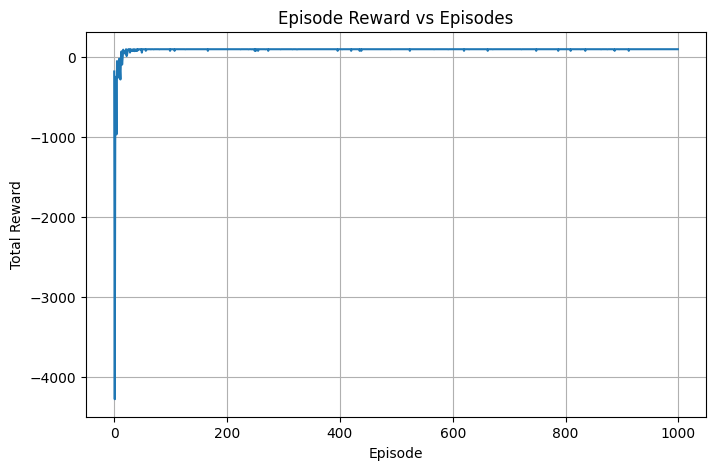

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(episode_rewards)
plt.title("Episode Reward vs Episodes")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

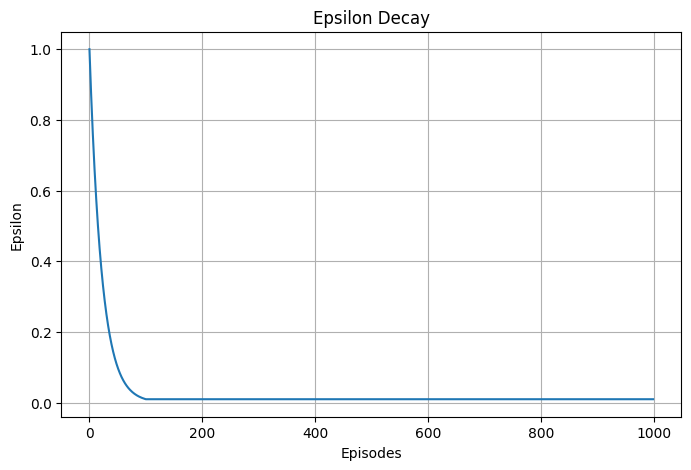

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epsilon_history)
plt.title("Epsilon Decay")
plt.xlabel("Episodes")
plt.ylabel("Epsilon")
plt.grid(True)
plt.show()

In [ ]:
print("Final Epsilon:", agent.epsilon)

Final Epsilon: 0.01


# Result
The agent successfully learned to navigate from the start state to the goal state while avoiding obstacles.
After multiple training episodes, the Q-table converged and stored higher values for actions leading toward the goal.
The learned policy enabled the agent to reach the goal using an efficient path.

In [ ]:
print(agent.q_table)

[[-17.06255373  42.612659   -16.93093248  -1.29012843]
 [-20.13118439  12.16546364  -2.13325526  -2.21553829]
 [-20.21281652  -2.14355666  -2.15264972 -19.22250295]
 [  0.           0.           0.           0.        ]
 [  0.           0.           0.           0.        ]
 [  5.28108416   3.56152633 -10.71791869  48.45851   ]
 [ -1.51707259  54.9539      10.33568879  -2.16058231]
 [ -2.20195307  -1.84126361  -2.02503749  -2.28599367]
 [-19.27200613 -18.61927824  -2.13425575 -13.05865518]
 [  0.           0.           0.           0.        ]
 [ -1.64451112  -1.68256519 -19.34811148  27.59747424]
 [  8.96366492  62.171        0.72008045   2.58227811]
 [ -1.83834294 -18.45242469  22.74258551 -14.26729762]
 [  0.           0.           0.           0.        ]
 [ -2.          -0.1         -2.          -2.        ]
 [ -1.58783167  -1.226513   -16.81244988   9.50731946]
 [ 13.45464636  70.19        -0.78812192  -7.71513056]
 [  0.           0.           0.           0.        ]
 [  0.    

In [ ]:
agent.epsilon = 0

In [ ]:
position = env.reset()
state = env.state_to_index(position)

done = False

while not done:

    env.render()

    action = agent.choose_action(state)

    next_position, reward, done = env.step(action)

    state = env.state_to_index(next_position)

    env.render()

A . . X X 
. . . . X 
. . . X . 
. . X . . 
. . . . G 

S . . X X 
A . . . X 
. . . X . 
. . X . . 
. . . . G 

S . . X X 
A . . . X 
. . . X . 
. . X . . 
. . . . G 

S . . X X 
. A . . X 
. . . X . 
. . X . . 
. . . . G 

S . . X X 
. A . . X 
. . . X . 
. . X . . 
. . . . G 

S . . X X 
. . . . X 
. A . X . 
. . X . . 
. . . . G 

S . . X X 
. . . . X 
. A . X . 
. . X . . 
. . . . G 

S . . X X 
. . . . X 
. . . X . 
. A X . . 
. . . . G 

S . . X X 
. . . . X 
. . . X . 
. A X . . 
. . . . G 

S . . X X 
. . . . X 
. . . X . 
. . X . . 
. A . . G 

S . . X X 
. . . . X 
. . . X . 
. . X . . 
. A . . G 

S . . X X 
. . . . X 
. . . X . 
. . X . . 
. . A . G 

S . . X X 
. . . . X 
. . . X . 
. . X . . 
. . A . G 

S . . X X 
. . . . X 
. . . X . 
. . X . . 
. . . A G 

S . . X X 
. . . . X 
. . . X . 
. . X . . 
. . . A G 

S . . X X 
. . . . X 
. . . X . 
. . X . . 
. . . . * 



In [ ]:
steps = 0

position = env.reset()
state = env.state_to_index(position)
done = False

agent.epsilon = 0    # Only exploit

while not done:
    action = agent.choose_action(state)
    next_position, reward, done = env.step(action)
    state = env.state_to_index(next_position)
    steps += 1

print("Steps to Goal:", steps)

Steps to Goal: 8


In [ ]:
policy = np.argmax(agent.q_table, axis=1)
print(policy)

[1 1 1 0 0 3 1 1 2 0 3 1 2 0 1 3 1 0 1 1 3 3 3 3 0]


In [ ]:
action_symbols = {
    0: "↑",   # Up
    1: "↓",   # Down
    2: "←",   # Left
    3: "→"    # Right
}

In [ ]:
for row in range(env.n):
    for col in range(env.n):

        position = (row, col)

        if position in env.obstacles:
            print("X", end=" ")

        elif position == env.goal:
            print("G", end=" ")

        elif position == env.start:
            print("S", end=" ")

        else:
            state = env.state_to_index(position)
            best_action = np.argmax(agent.q_table[state])
            print(action_symbols[best_action], end=" ")

    print()

S ↓ ↓ X X 
→ ↓ ↓ ← X 
→ ↓ ← X ↓ 
→ ↓ X ↓ ↓ 
→ → → → G 


# Conclusion
In this project, a Q-learning agent was implemented to solve the GridWorld navigation problem. Through repeated interaction with the environment, the agent learned an optimal policy without prior knowledge of the environment. The results demonstrate that Q-learning is effective for discrete state-action problems and can successfully learn optimal paths using rewards and penalties.

### Performance Summary
| Metric | Value |
|---------|-------|
| Grid Size | 5 × 5 |
| Obstacles | 5 |
| Training Episodes | 1000 |
| Learning Rate (α) | 0.1 |
| Discount Factor (γ) | 0.9 |
| Initial Epsilon | 1.0 |
| Final Epsilon | 0.01 |
| Goal Reached | Yes |
| Steps to Reach Goal | 8 |